<a href="https://colab.research.google.com/github/cmburban/MAT-422/blob/main/MAT422_Section_3_2_Limits_Derivatives_Taylor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT 422 - Section 3.2: Limits, Derivatives, and Taylor's Theorem

**Topics:** Limits and continuity, Derivatives, Taylor's theorem

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import math

np.set_printoptions(precision=6, suppress=True)

## 3.2.1 Limits and Continuity

A limit describes the value that a function approaches as the input gets closer to a particular point. A function is continuous at a point when its limit at that point equals the value of the function.

I will use the function f(x) = x² + 2x + 1 and examine what happens as x approaches 2. Since this is a polynomial, it should be continuous at x = 2.

In [10]:
def f(x):
    return x**2 + 2*x + 1

x_values = np.array([1.9, 1.99, 1.999, 2.001, 2.01, 2.1])

print("x values:")
print(x_values)

print("\nf(x) values:")
print(f(x_values))

print("\nf(2) =", f(2))

x values:
[1.9   1.99  1.999 2.001 2.01  2.1  ]

f(x) values:
[8.41     8.9401   8.994001 9.006001 9.0601   9.61    ]

f(2) = 9


The values of f(x) approach 9 as x gets closer to 2 from both sides. The actual value f(2) is also 9, so the limit and function value agree. This shows that the function is continuous at x = 2.

### Visualizing the Limit

A graph can make the idea of a limit easier to see. I will plot the function near x = 2 and mark the point where the limit is being evaluated.

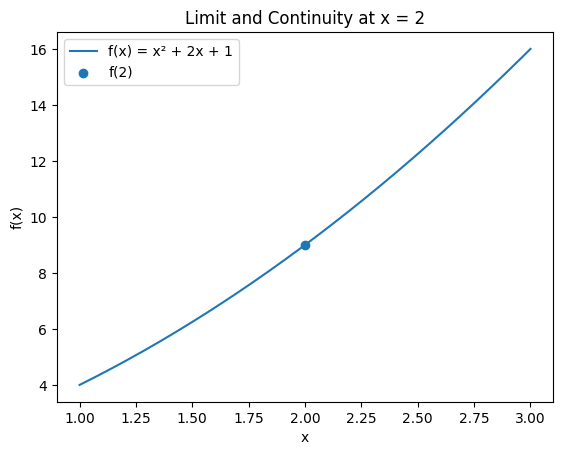

In [11]:
x_plot = np.linspace(1, 3, 200)
y_plot = f(x_plot)

plt.plot(x_plot, y_plot, label="f(x) = x² + 2x + 1")
plt.scatter([2], [f(2)], label="f(2)")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Limit and Continuity at x = 2")
plt.legend()

plt.show()

The graph shows a smooth curve near x = 2 with no break or jump. The function approaches the same value from both sides, and the point at x = 2 is part of the curve. This provides a visual check that the function is continuous at x = 2.

## 3.2.2 Derivatives

A derivative measures how quickly a function changes as its input changes. Geometrically, the derivative gives the slope of the tangent line to a function at a particular point.

For the function f(x) = x² + 2x + 1, the derivative is f'(x) = 2x + 2. I will compare the analytical derivative with a numerical approximation.

In [12]:
def f_prime(x):
    return 2*x + 2

x0 = 2

# Numerical derivative using a small change in x
h = 0.0001

numerical_derivative = (
    f(x0 + h) - f(x0)
) / h

exact_derivative = f_prime(x0)

print("Numerical derivative:", numerical_derivative)
print("Exact derivative:", exact_derivative)
print("Difference:", abs(numerical_derivative - exact_derivative))

Numerical derivative: 6.000100000012054
Exact derivative: 6
Difference: 0.00010000001205412445


The numerical derivative is very close to the exact derivative of 6. This shows that using a very small change in x can provide a good approximation of the derivative at a point.

### Visualizing the Derivative

The derivative at a point gives the slope of the tangent line. I will plot the function near x = 2 along with the tangent line at that point.

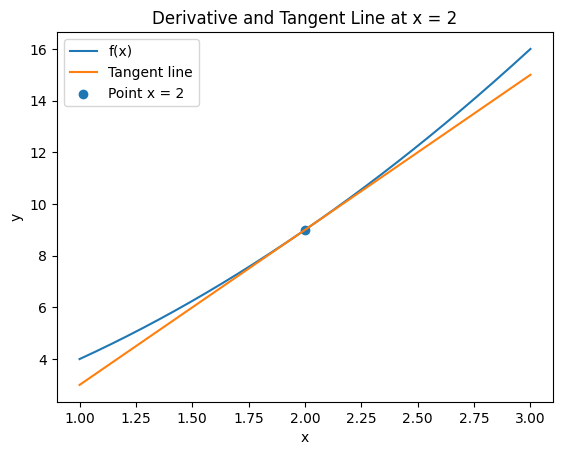

In [13]:
x_plot = np.linspace(1, 3, 200)
y_plot = f(x_plot)

slope = f_prime(x0)
y0 = f(x0)

tangent_line = y0 + slope * (x_plot - x0)

plt.plot(x_plot, y_plot, label="f(x)")
plt.plot(x_plot, tangent_line, label="Tangent line")
plt.scatter([x0], [y0], label="Point x = 2")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Derivative and Tangent Line at x = 2")
plt.legend()

plt.show()

The tangent line touches the function at x = 2 and has a slope of 6. This matches the value of the derivative at that point. The graph helps show that the derivative represents the local rate of change of the function.

## 3.2.3 Taylor's Theorem

Taylor's theorem allows a function to be approximated near a point using a polynomial. The more terms that are included in the Taylor polynomial, the more accurately it can approximate the original function near the point.

I will use f(x) = eˣ and approximate it around x = 0. The Taylor series for eˣ begins with 1 + x + x²/2! + x³/3! + ...

In [14]:
def taylor_exp(x, degree):
    approximation = np.zeros_like(x, dtype=float)

    for n in range(degree + 1):
        approximation += x**n / math.factorial(n)

    return approximation


x = np.linspace(-2, 2, 200)

y_actual = np.exp(x)

taylor_1 = taylor_exp(x, 1)
taylor_2 = taylor_exp(x, 2)
taylor_4 = taylor_exp(x, 4)

print("e^1 =", np.exp(1))
print("Degree 1 approximation at x = 1:", taylor_exp(np.array([1.0]), 1)[0])
print("Degree 2 approximation at x = 1:", taylor_exp(np.array([1.0]), 2)[0])
print("Degree 4 approximation at x = 1:", taylor_exp(np.array([1.0]), 4)[0])

e^1 = 2.718281828459045
Degree 1 approximation at x = 1: 2.0
Degree 2 approximation at x = 1: 2.5
Degree 4 approximation at x = 1: 2.708333333333333


The degree-1 polynomial gives a rough approximation of eˣ near x = 0. Adding more terms makes the approximation more accurate. The degree-4 approximation should be much closer to the actual value of e at x = 1.

### Visualizing Taylor Approximations

The following graph compares the actual function eˣ with Taylor polynomials of different degrees. This shows how increasing the degree improves the approximation near the point x = 0.

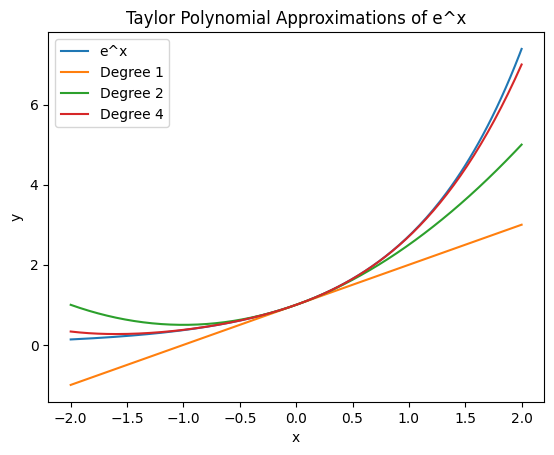

In [15]:
plt.plot(x, y_actual, label="e^x")
plt.plot(x, taylor_1, label="Degree 1")
plt.plot(x, taylor_2, label="Degree 2")
plt.plot(x, taylor_4, label="Degree 4")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Taylor Polynomial Approximations of e^x")
plt.legend()

plt.show()

The graph shows that the Taylor polynomials approximate eˣ most closely near x = 0. The degree-4 polynomial follows the original function more closely than the lower-degree approximations. This demonstrates how adding more terms can improve the accuracy of a Taylor approximation.

## End of Notebook Reflection

In this notebook, I learned how limits can be used to understand what a function approaches as the input gets closer to a certain value. The example showed that a function is continuous when the limit and the actual function value agree.
I also learned that a derivative describes the rate at which a function changes. The numerical derivative was very close to the exact derivative, and the tangent-line graph helped show how the derivative represents the slope of a function at a specific point.
Lastly, I learned how Taylor's theorem can approximate a function using a polynomial. In my example, adding more terms made the Taylor polynomial a better approximation of \(e^x\), especially near the point where the approximation was centered. Overall, these examples helped me understand how limits, derivatives, and Taylor approximations can be used to study and approximate functions.

## References

[Mathematical Methods in Data Science - Elsevier (2023)](https://doi.org/10.1016/B978-0-44-318679-0.00007-7)

[Numpy - Singular Value Decomposition](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html)

[Matplotlib](https://matplotlib.org/stable/)

[OpenAI - ChatGPT (2026)](https://chatgpt.com)

## Submission Checklist

- I explained each concept in words before or after the code. [DONE]
- I verified important claims numerically or visually. [DONE]
- I changed or extended at least one example so the notebook reflects my own work. [DONE]
- I ran the notebook from top to bottom without errors. [DONE]
- I saved the notebook from Google Colab directly to GitHub, following the course instructions. [DONE]